In [ ]:
import torch
import torch.nn.functional as F
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

### Import the data

In [ ]:
%run  Data_preparation_TCGA.ipynb

### Import the model

In [ ]:
from Classification_model import *

# Training

The data loader is divided into two parts to facilitate evaluation, allowing the model to be assessed either specifically on the test set or on the entire dataset as a whole.

In [ ]:
train_loader = DataLoader(training_set, batch_size=1024, shuffle=True)
test_loader = DataLoader(testing_set, batch_size=5096, shuffle=False)

Initialize the models:  
model is the graph-based model, while model_r is the model initialized with a random graph structure.

In [ ]:
import pickle
torch.manual_seed(0)

num_hiddens_genotype = 16
num_hiddens_final = 16

model = Drugcell_Vae(term_size_map, term_direct_gene_map, dG, num_genes, 
                 root, num_hiddens_genotype, num_hiddens_final, n_class = len(cancer_2_idx))

with open("random_graphs/random_graph.pkl", "rb") as f:
    dG1 = pickle.load(f)

model_r = Drugcell_Vae(term_size_map, term_direct_gene_map, dG1, num_genes, 
                 root, num_hiddens_genotype, num_hiddens_final, n_class = len(cancer_2_idx))

Define the plot size

In [72]:
plt.rcParams.update({
    'font.size': 16,        
    'axes.titlesize': 18,   
    'axes.labelsize': 16,   
    'xtick.labelsize': 14,  
    'ytick.labelsize': 14,  
    'legend.fontsize': 14   
})

Save the models' paths for analysis.  
The models are too big to upload in Github. These files are uploaded as a zip file in the Releases named 'Saved'. If want to try the models, download the zip file from 'Saved' and extract it to the 'Saved_models_and_results' folder.

In [ ]:
model_paths = [
    "Saved_models_and_results/model_classification_no_teacher.pt",
    "Saved_models_and_results/model_classification_no_teacher_random.pt",
    "Saved_models_and_results/model_classification_freeze_encoder.pt",
    "Saved_models_and_results/model_classification_freeze_encoder_random.pt",
    "Saved_models_and_results/model_classification_set_teacher.pt",
    "Saved_models_and_results/model_classification_set_teacher_random.pt",
    "Saved_models_and_results/model_classification_distillation.pt",
    "Saved_models_and_results/model_classification_distillation_random.pt"
]

The following function gathers the model’s outputs across one or multiple data loaders.  
It extracts logits, labels, and the final embeddings from each batch without computing gradients.

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

@torch.no_grad()
def collect_outputs(model, loaders):
    if not isinstance(loaders, (list, tuple)):
        loaders = [loaders]
    all_logits, all_labels, all_embeds = [], [], []
    for loader in loaders:
        for x, y in loader:
            x = x.to(DEVICE, non_blocking=True)
            logits, mu, log_var, aux_out_map, aux_cancer_map, term_NN_out_map, term_original_children = model(x)
            all_logits.append(logits.detach().cpu())
            all_labels.append(y.detach().cpu().long())
            all_embeds.append(term_NN_out_map['final'].detach().cpu()) 
    return (
        torch.cat(all_logits, 0),
        torch.cat(all_labels, 0),
        torch.cat(all_embeds, 0)
    )

This function computes **accuracy**, **weighted recall**, and **weighted F1-score** based on model predictions.   
It builds a confusion matrix and derives per-class precision, recall, and F1 values to calculate the overall weighted metrics.

In [ ]:
def metrics_acc_recall_f1(logits, labels):
    preds = torch.argmax(logits, dim=1)
    N = labels.numel()
    accuracy = (preds == labels).sum().item() / N

    C = logits.size(1)
    eps = 1e-12
    cm = torch.zeros((C, C), dtype=torch.long)
    for t, p in zip(labels, preds):
        cm[t, p] += 1

    per_prec, per_rec, per_f1, support = [], [], [], []
    for c in range(C):
        TP = cm[c, c].item()
        FP = (cm[:, c].sum() - cm[c, c]).item()
        FN = (cm[c, :].sum() - cm[c, c]).item()
        prec = TP / (TP + FP + eps)
        rec  = TP / (TP + FN + eps)
        f1   = 2 * prec * rec / (prec + rec + eps)
        per_prec.append(prec)
        per_rec.append(rec)
        per_f1.append(f1)
        support.append(cm[c, :].sum().item())

    total = sum(support) + eps
    weighted_recall = sum(r * s for r, s in zip(per_rec, support)) / total
    weighted_f1     = sum(f * s for f, s in zip(per_f1, support)) / total

    return pd.DataFrame([{
        "Accuracy": accuracy,
        "Recall": weighted_recall,
        "F1": weighted_f1
    }])


This function visualizes the **sample embeddings** using t-SNE dimensionality reduction.  
Each point represents a sample, colored according to its **cancer type**.  
If provided, the mapping `idx_2_cancer` is used to convert label indices into cancer-type names for clearer interpretation.


In [ ]:
def plot_tsne(embeds, labels, idx_2_cancer=None, title="t-SNE map"):
    tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
    embeds_2d = tsne.fit_transform(embeds.numpy())

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        embeds_2d[:, 0], embeds_2d[:, 1],
        c=labels.numpy(), cmap="tab20", alpha=0.7, s=8
    )

    # turn the value label to the name of cancer type
    unique_labels = torch.unique(labels)
    handles = []
    for ul in unique_labels:
        color = scatter.cmap(scatter.norm(ul.item()))
        if idx_2_cancer is not None:
            label_text = idx_2_cancer.get(int(ul.item()), str(ul.item()))
        else:
            label_text = str(ul.item())

        handles.append(plt.Line2D([], [], marker="o", linestyle="",
                                  color=color, label=label_text))

    plt.legend(handles=handles, title="Cancer Types",
               bbox_to_anchor=(1.05, 1), loc="upper left", ncol=2)
    plt.title(title)
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_2468727/2071139894.py:123: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_used = torch.load(model_path, map_location=DEVICE)



===== Evaluation（model_classification_no_teacher.pt） =====
   Accuracy    Recall        F1
0  0.848943  0.848943  0.849149


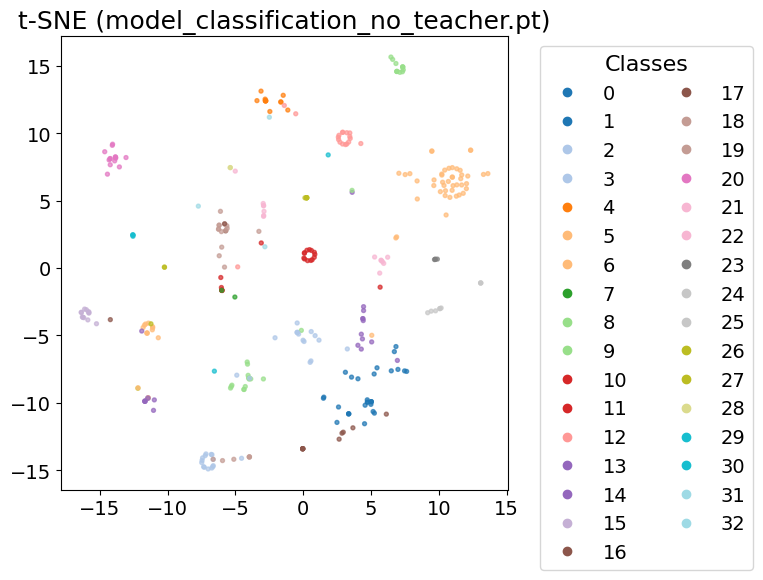

/tmp/ipykernel_2468727/2071139894.py:123: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_used = torch.load(model_path, map_location=DEVICE)



===== Evaluation（model_classification_no_teacher_random.pt） =====
   Accuracy    Recall        F1
0  0.848943  0.848943  0.849885


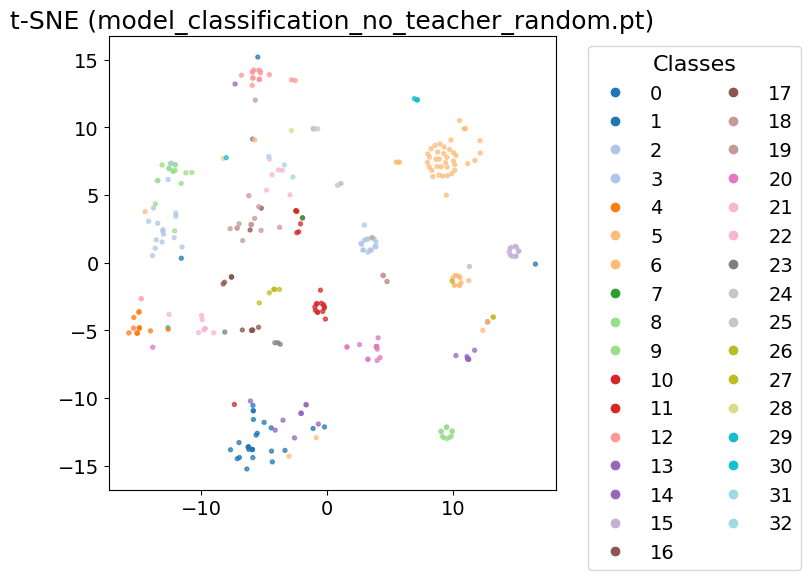

/tmp/ipykernel_2468727/2071139894.py:123: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_used = torch.load(model_path, map_location=DEVICE)



===== Evaluation（model_classification_freeze_encoder.pt） =====
   Accuracy    Recall        F1
0  0.867069  0.867069  0.864941


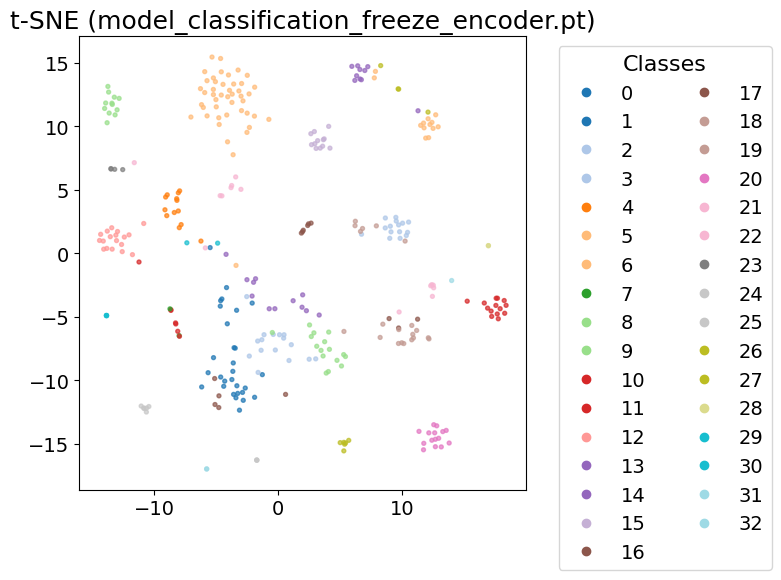

/tmp/ipykernel_2468727/2071139894.py:123: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_used = torch.load(model_path, map_location=DEVICE)



===== Evaluation（model_classification_freeze_encoder_random.pt） =====
   Accuracy    Recall        F1
0  0.797583  0.797583  0.799501


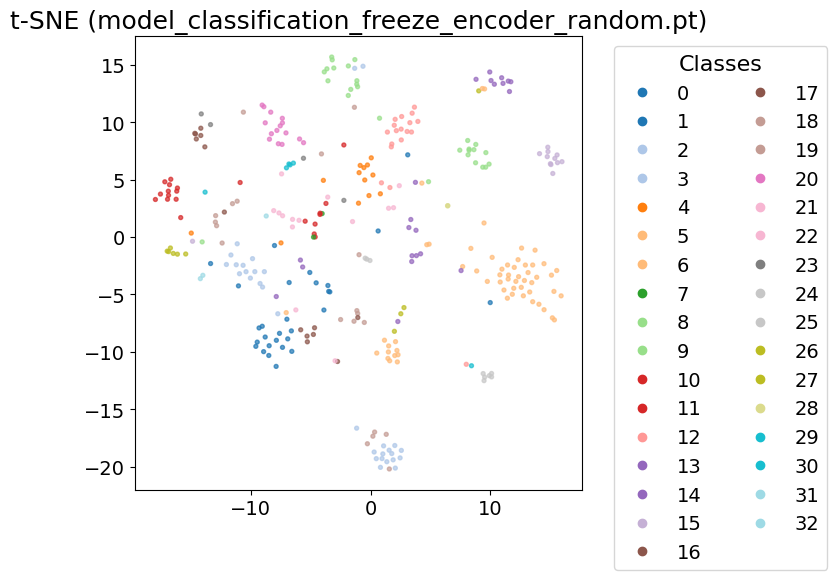

/tmp/ipykernel_2468727/2071139894.py:123: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_used = torch.load(model_path, map_location=DEVICE)



===== Evaluation（model_classification_set_teacher.pt） =====
   Accuracy    Recall       F1
0  0.845921  0.845921  0.83825


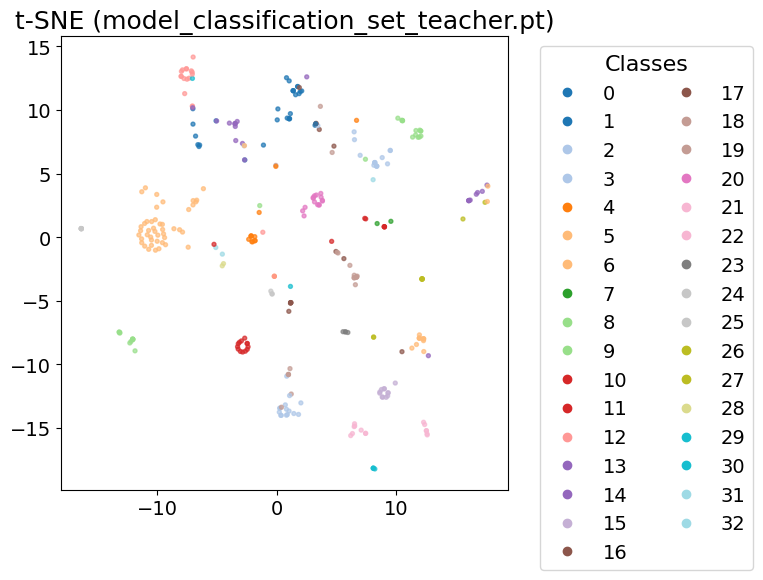

/tmp/ipykernel_2468727/2071139894.py:123: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_used = torch.load(model_path, map_location=DEVICE)



===== Evaluation（model_classification_set_teacher_random.pt） =====
   Accuracy    Recall        F1
0  0.830816  0.830816  0.827455


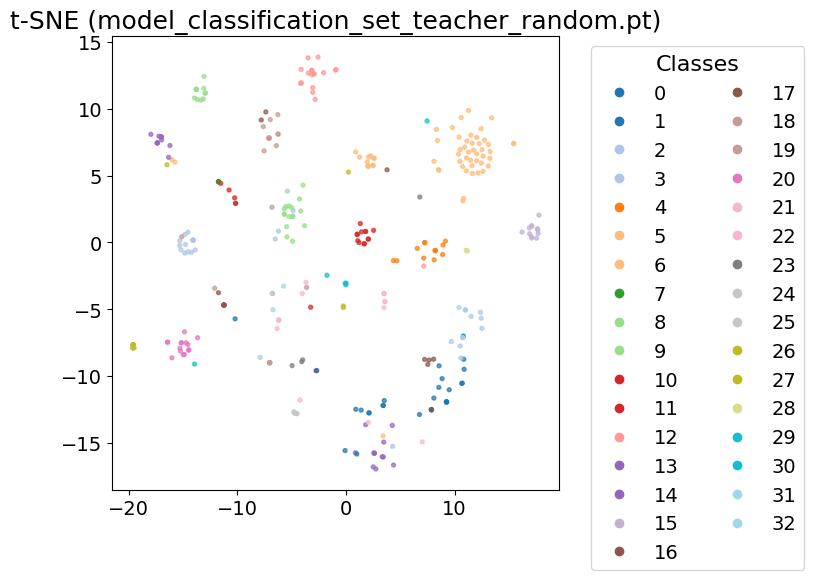

/tmp/ipykernel_2468727/2071139894.py:123: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_used = torch.load(model_path, map_location=DEVICE)



===== Evaluation（model_classification_distillation.pt） =====
   Accuracy    Recall        F1
0  0.833837  0.833837  0.834247


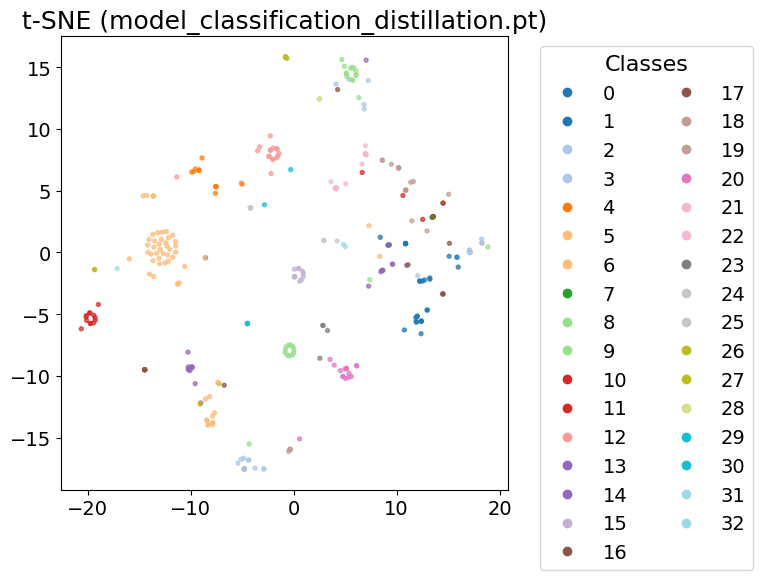

/tmp/ipykernel_2468727/2071139894.py:123: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_used = torch.load(model_path, map_location=DEVICE)



===== Evaluation（model_classification_distillation_random.pt） =====
   Accuracy   Recall        F1
0   0.81571  0.81571  0.811164


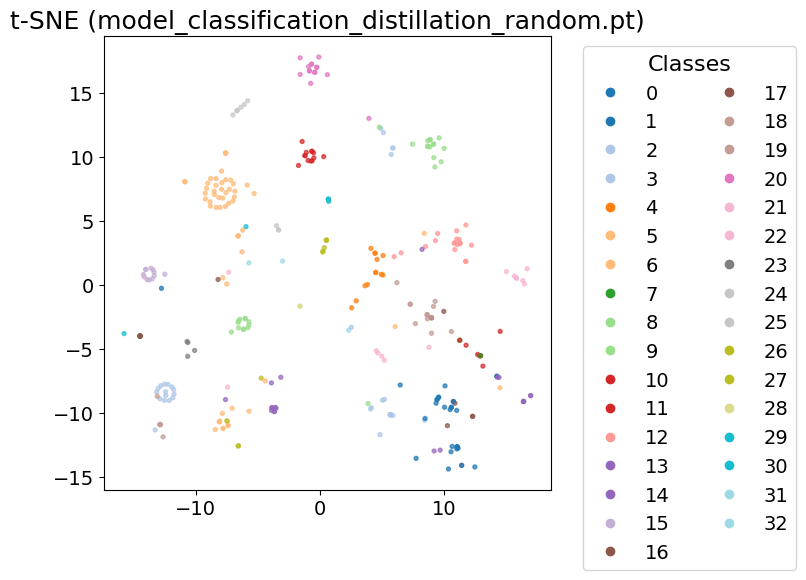

In [ ]:
for model_path in model_paths:
    if "random" in model_path:
        model_used = model_r
    else:
        model_used = model

    model_used = torch.load(model_path, map_location=DEVICE)
    model_used.to(DEVICE)
    model_used.eval()

    
    loaders_all = [train_loader, test_loader] 

    logits, labels, embeds = collect_outputs(model_used, test_loader)
    # If prefer test with whole dataset, then:
    # logits, labels, embeds = collect_outputs(model_used, test_loader)

    df = metrics_acc_recall_f1(logits, labels)
    print(f"\n===== Evaluation（{model_path}） =====")
    print(df)

    plot_tsne(embeds, labels, idx_2_cancer=idx_2_cancer, 
          title=f"t-SNE ({model_path})")

